## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = True #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Some checks on the data

1. Let's check if column naming is consistent (inDs).

In [6]:
series_based_on_sample_name = pd.Series(inds_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [7]:
series_based_on_column = inds_df['seria'].reset_index(drop=True)

In [8]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything is fine. For inKs:

In [9]:
series_based_on_sample_name = pd.Series(inks_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [10]:
series_based_on_column = inks_df['seria'].reset_index(drop=True)

In [11]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything ok.

2. Let's check if naming is consistent across two sheets (i.e. for inDs and for inKs).

In [12]:
series_from_inds_sheet = inds_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [13]:
series_from_inks_sheet = inks_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [14]:
np.all(series_from_inds_sheet == series_from_inks_sheet)

False

It's not consistent, but it's not the problem, cause rows in both tables correspond to each other.

In [15]:
inks_df.shape == inds_df.shape

True

### Joining corresponding samples from inds and inks into one table

In [16]:
inks_df = inks_df.reset_index(drop=False)

In [17]:
inds_df = inds_df.reset_index(drop=False)

In [18]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inds', lsuffix='_inks')

In [19]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [20]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [21]:
inDKs_df.dropna(inplace=True)

In [22]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [23]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

### Creating features and labels matrices

In [24]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [25]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

In [26]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [27]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    ind_train, ind_test = train_test_split(indices, test_size=0.3, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.3, random_state=1)

In [28]:
partition = {'train': ind_train_all,
            'test': ind_test_all}

In [29]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [30]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y =y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [31]:
train_dataset = InksDataset(X=X_train, y=y_train)
test_dataset = InksDataset(X=X_test, y=y_test)

In [32]:
# loader = DataLoader(list(zip(X_train, y_train)), shuffle=True, batch_size=100)
# test_loader = DataLoader(list(zip(X_test, y_test)))

train_loader = DataLoader(train_dataset, shuffle=False, batch_size=100)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [33]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(29, 50),
        #nn.Dropout(),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50,29))
    def forward(self, x):
        return self.seq(x)

## Training

In [34]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=29, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=29, bias=True)
  )
)


In [35]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
    print('Len of loader:')
    print(len(loader))
    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [36]:
EPOCHS = 1000
loss_fn = nn.L1Loss()
#optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_tloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(test_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_tloss += loss.item()
    
    print('Len of test_loader')
    print(len(test_loader))
    avg_tloss = float(running_tloss / len(test_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_tloss))
    
    train_losses.append(avg_loss)
    test_losses.append(avg_tloss)

    epoch_number += 1

EPOCH 1:
Len of loader:
17
Len of test_loader
720
LOSS train 5.475544529802659 test 3.2867645270915493
EPOCH 2:
Len of loader:
17
Len of test_loader
720
LOSS train 5.4047474089790795 test 3.2085304089718396
EPOCH 3:
Len of loader:
17
Len of test_loader
720
LOSS train 5.338865637779236 test 3.1340041912678216
EPOCH 4:
Len of loader:
17
Len of test_loader
720
LOSS train 5.276105207555434 test 3.0624773021787406
EPOCH 5:
Len of loader:
17
Len of test_loader
720
LOSS train 5.2160984768587 test 2.993882266825272
EPOCH 6:
Len of loader:
17
Len of test_loader
720
LOSS train 5.159021791289835 test 2.929702932159934
EPOCH 7:
Len of loader:
17
Len of test_loader
720
LOSS train 5.105721957543317 test 2.8688704962531726
EPOCH 8:
Len of loader:
17
Len of test_loader
720
LOSS train 5.055600523948669 test 2.81112997573283
EPOCH 9:
Len of loader:
17
Len of test_loader
720
LOSS train 5.008491544162526 test 2.756709484900865
EPOCH 10:
Len of loader:
17
Len of test_loader
720
LOSS train 4.963795598815469

Len of test_loader
720
LOSS train 3.9729366653105793 test 1.6548209676001635
EPOCH 81:
Len of loader:
17
Len of test_loader
720
LOSS train 3.9656205352614906 test 1.6483202885732882
EPOCH 82:
Len of loader:
17
Len of test_loader
720
LOSS train 3.958468307467068 test 1.6418331178319123
EPOCH 83:
Len of loader:
17
Len of test_loader
720
LOSS train 3.9512014739653645 test 1.6365617868904438
EPOCH 84:
Len of loader:
17
Len of test_loader
720
LOSS train 3.9446914932307076 test 1.6299917604256835
EPOCH 85:
Len of loader:
17
Len of test_loader
720
LOSS train 3.93777035965639 test 1.6238750351489417
EPOCH 86:
Len of loader:
17
Len of test_loader
720
LOSS train 3.930844254353467 test 1.6177201152986123
EPOCH 87:
Len of loader:
17
Len of test_loader
720
LOSS train 3.9241649526007034 test 1.6120012034144666
EPOCH 88:
Len of loader:
17
Len of test_loader
720
LOSS train 3.9174981187371647 test 1.6067853022884164
EPOCH 89:
Len of loader:
17
Len of test_loader
720
LOSS train 3.9111657826339497 test 1

Len of test_loader
720
LOSS train 3.6431762751410988 test 1.4145136354801555
EPOCH 161:
Len of loader:
17
Len of test_loader
720
LOSS train 3.641963846543256 test 1.4142199222619334
EPOCH 162:
Len of loader:
17
Len of test_loader
720
LOSS train 3.6402936998535607 test 1.4142555467163522
EPOCH 163:
Len of loader:
17
Len of test_loader
720
LOSS train 3.639382565722746 test 1.4147137188300904
EPOCH 164:
Len of loader:
17
Len of test_loader
720
LOSS train 3.638296961784363 test 1.4142269515691117
EPOCH 165:
Len of loader:
17
Len of test_loader
720
LOSS train 3.6369141778525185 test 1.4142138419672847
EPOCH 166:
Len of loader:
17
Len of test_loader
720
LOSS train 3.6354416924364426 test 1.4141076105543309
EPOCH 167:
Len of loader:
17
Len of test_loader
720
LOSS train 3.634353048661176 test 1.4140586265259318
EPOCH 168:
Len of loader:
17
Len of test_loader
720
LOSS train 3.63328419713413 test 1.4144750502426178
EPOCH 169:
Len of loader:
17
Len of test_loader
720
LOSS train 3.6326198612942413

Len of test_loader
720
LOSS train 3.574681611622081 test 1.4038291471906834
EPOCH 239:
Len of loader:
17
Len of test_loader
720
LOSS train 3.574213922023773 test 1.4042382090766397
EPOCH 240:
Len of loader:
17
Len of test_loader
720
LOSS train 3.5734887298415687 test 1.40264915653194
EPOCH 241:
Len of loader:
17
Len of test_loader
720
LOSS train 3.572588191312902 test 1.402920495470365
EPOCH 242:
Len of loader:
17
Len of test_loader
720
LOSS train 3.5721366124994614 test 1.402627550634659
EPOCH 243:
Len of loader:
17
Len of test_loader
720
LOSS train 3.571336399106418 test 1.4028689994890657
EPOCH 244:
Len of loader:
17
Len of test_loader
720
LOSS train 3.5705822548445534 test 1.4020195079036057
EPOCH 245:
Len of loader:
17
Len of test_loader
720
LOSS train 3.570009147419649 test 1.402298596708311
EPOCH 246:
Len of loader:
17
Len of test_loader
720
LOSS train 3.569045466535232 test 1.401843348124789
EPOCH 247:
Len of loader:
17
Len of test_loader
720
LOSS train 3.568476792644052 test 1

KeyboardInterrupt: 

In [35]:
# Obserwacje: jeżeli wyrzucam dane symulowane osobno, albo rzeczywiste osobno,
#to dzieje się tak, że test loss jest mniejszy od treningowego.
# To nie jest wina Dropoutu, bo sprawdziłam też bez dropoutu.
# Nie jest to też wina L1Loss, sprawdziłam MSELoss i jest ta sama historia.

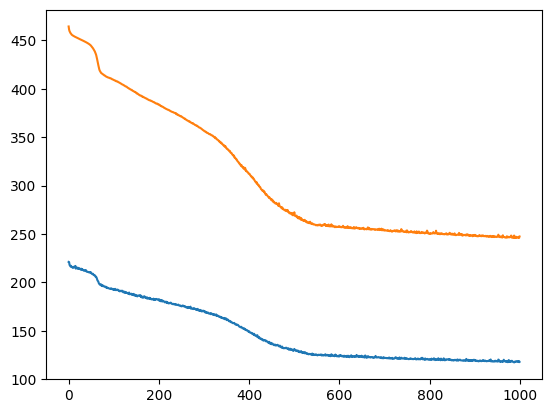

In [37]:
#no keeping one sample together
plt.plot(train_losses) #all
plt.plot(test_losses)

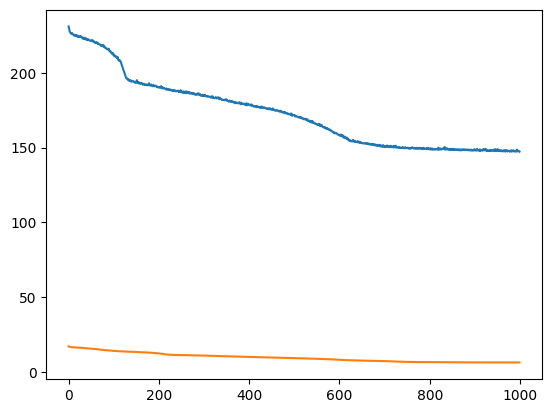

In [35]:
#no keeping one sample together
plt.plot(train_losses) #simulated
plt.plot(test_losses)

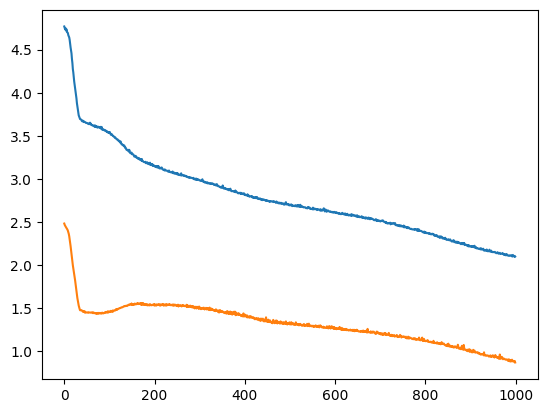

In [35]:
#no keeping one sample together
plt.plot(train_losses) #real
plt.plot(test_losses)

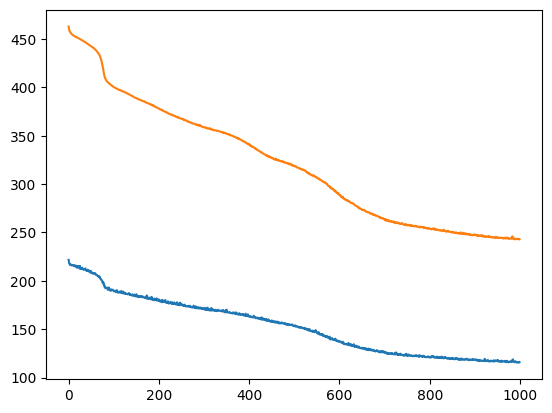

In [37]:
plt.plot(train_losses) #all
plt.plot(test_losses)

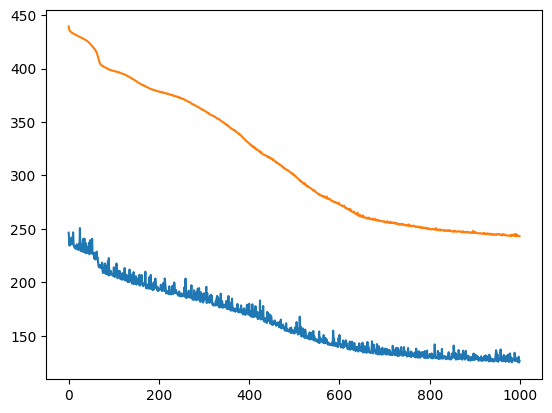

In [36]:
plt.plot(train_losses) #:3500
plt.plot(test_losses)

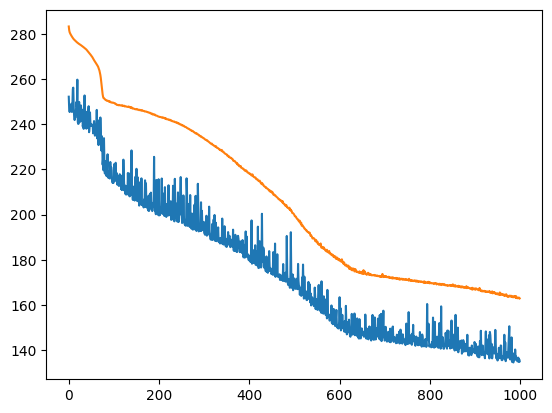

In [36]:
plt.plot(train_losses) #:3350
plt.plot(test_losses)

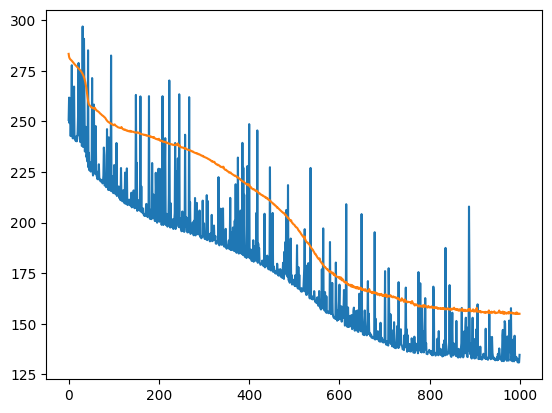

In [36]:
plt.plot(train_losses) #:3325
plt.plot(test_losses)

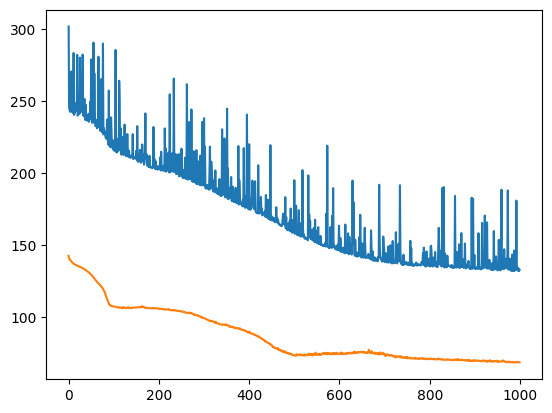

In [36]:
plt.plot(train_losses) #:3300
plt.plot(test_losses)

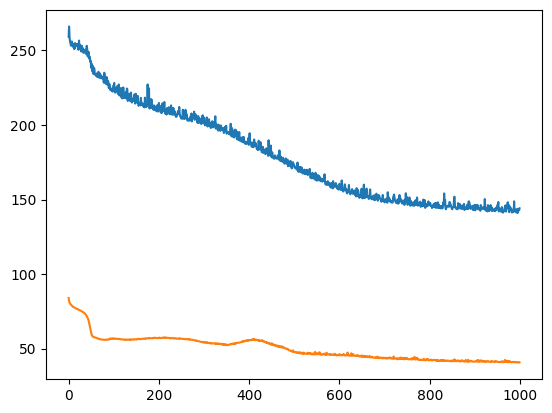

In [36]:
plt.plot(train_losses) #:3250
plt.plot(test_losses)

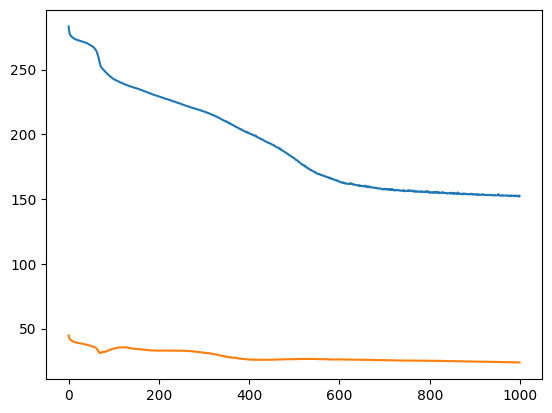

In [36]:
plt.plot(train_losses) #:3000
plt.plot(test_losses)

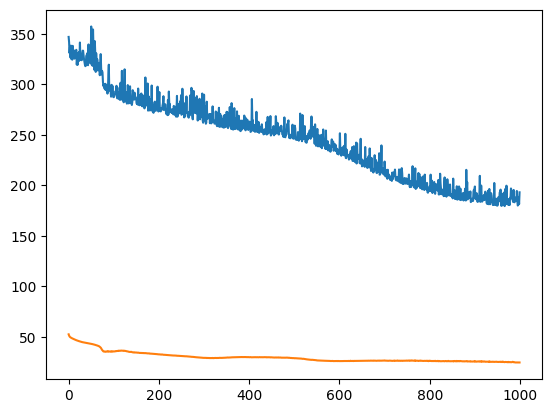

In [36]:
plt.plot(train_losses) #:2500
plt.plot(test_losses)

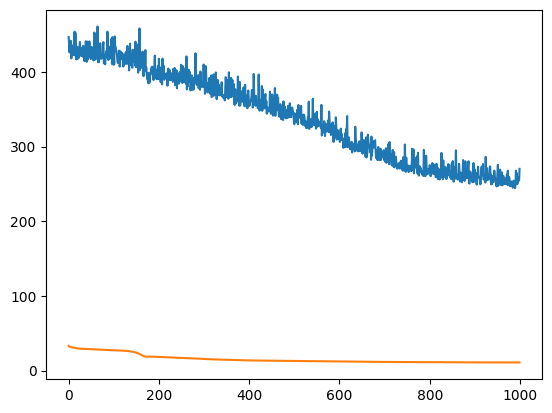

In [36]:
plt.plot(train_losses) #:1500
plt.plot(test_losses)

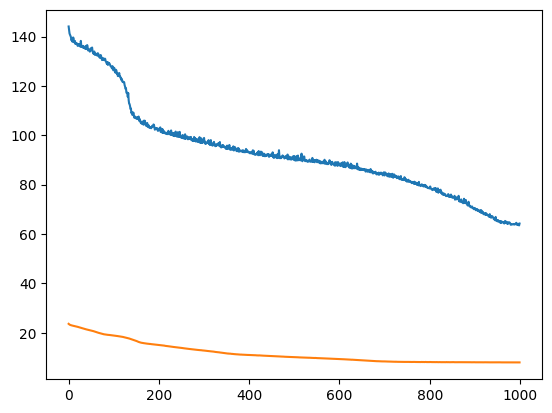

In [36]:
plt.plot(train_losses) #:1430
plt.plot(test_losses)

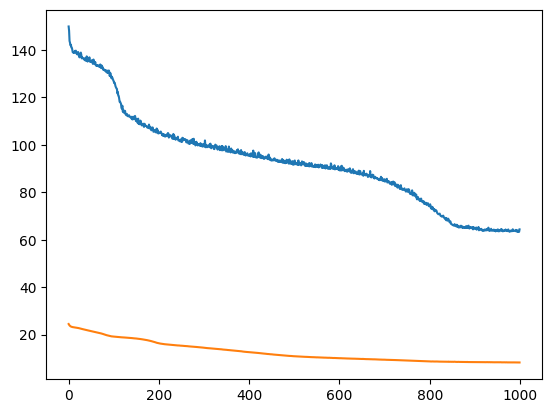

In [36]:
plt.plot(train_losses) #:1425
plt.plot(test_losses)

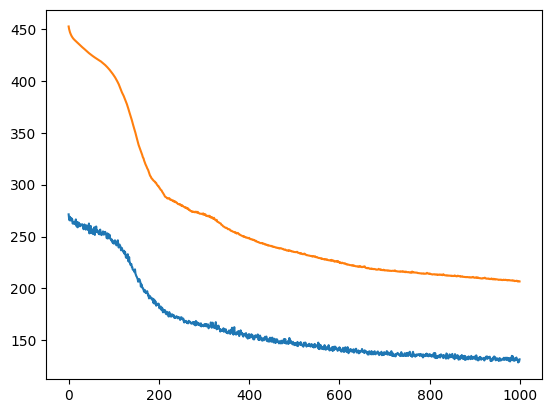

In [36]:
plt.plot(train_losses) #1025:1885
plt.plot(test_losses)

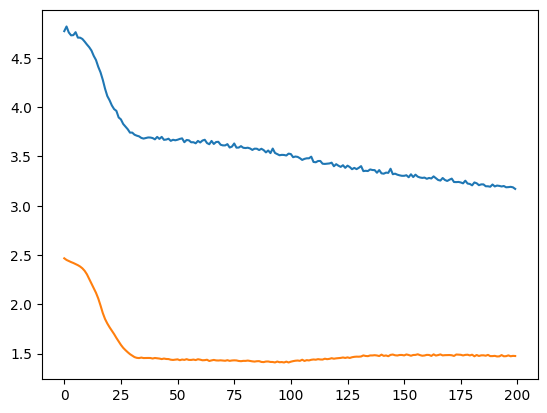

In [37]:
plt.plot(train_losses) #1425:
plt.plot(test_losses)

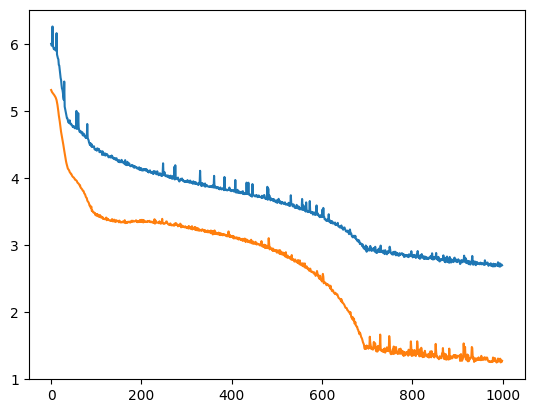

In [36]:
plt.plot(train_losses) #1424:
plt.plot(test_losses)

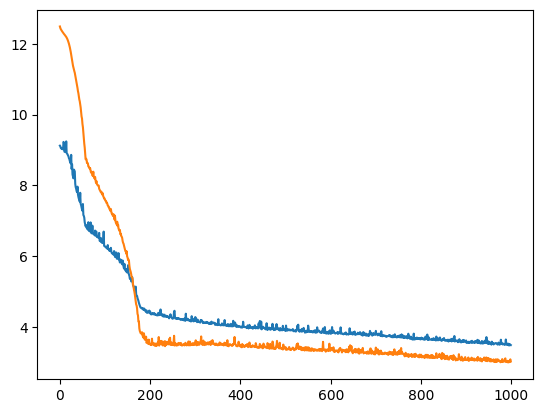

In [36]:
plt.plot(train_losses) #1421:
plt.plot(test_losses)

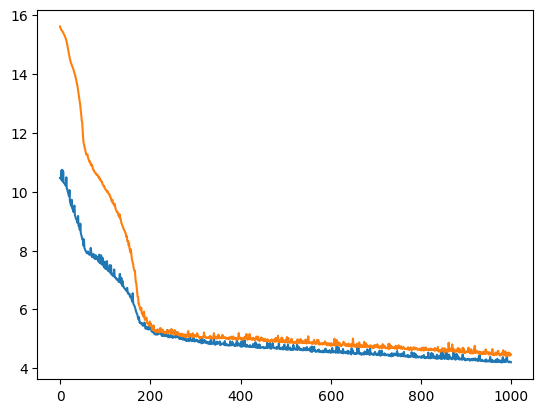

In [36]:
plt.plot(train_losses) #1420:
plt.plot(test_losses)

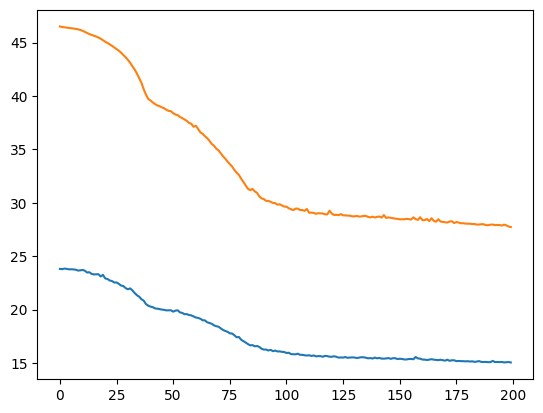

In [36]:
plt.plot(train_losses) #1410:
plt.plot(test_losses)

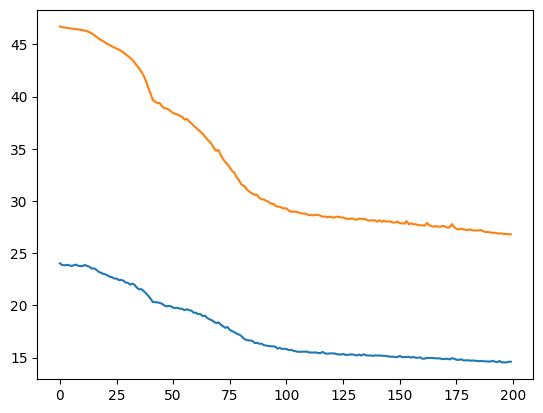

In [36]:
plt.plot(train_losses) #1400:
plt.plot(test_losses)

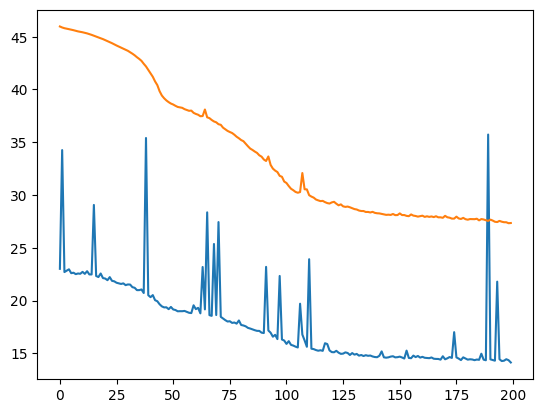

In [36]:
plt.plot(train_losses) #1375:
plt.plot(test_losses)

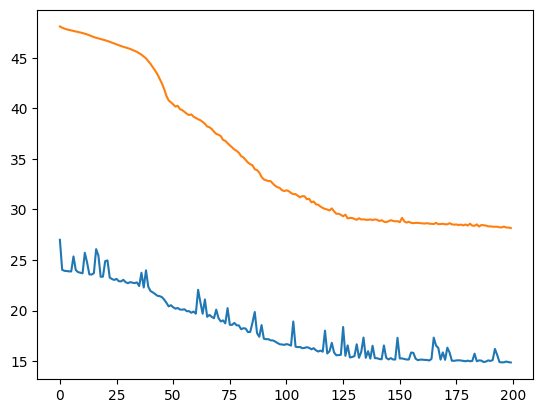

In [36]:
plt.plot(train_losses) #1325:
plt.plot(test_losses)

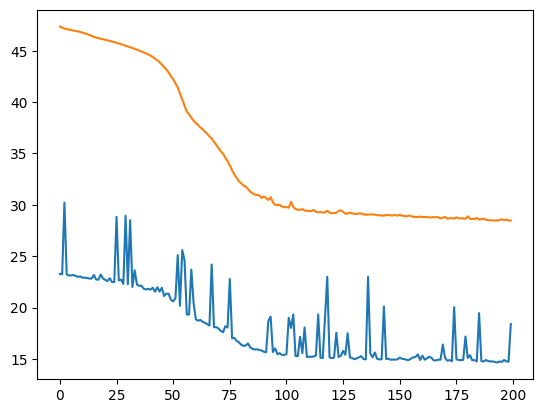

In [37]:
plt.plot(train_losses) #1225:
plt.plot(test_losses)

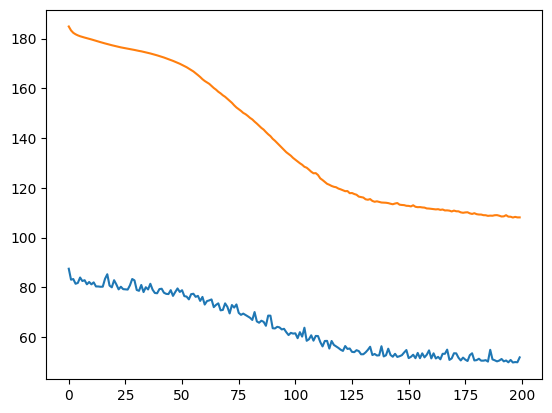

In [36]:
plt.plot(train_losses) #1025:
plt.plot(test_losses)

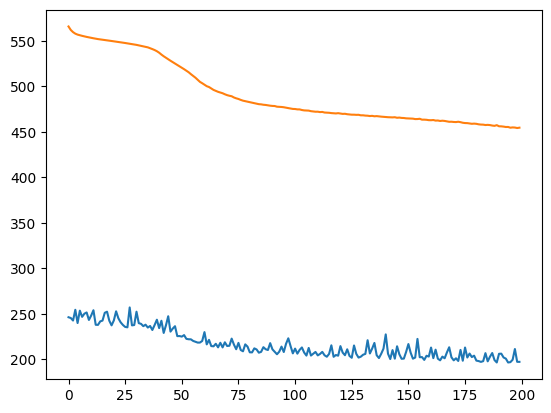

In [36]:
plt.plot(train_losses) #625:
plt.plot(test_losses)

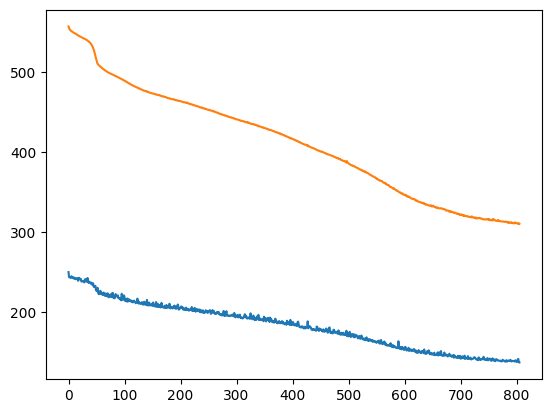

In [36]:
plt.plot(train_losses) #425:
plt.plot(test_losses)

In [36]:
np.array((labels-outputs).cpu()).round(2)

array([[ 0.44,  1.46,  0.23,  0.34, -0.01,  0.29,  0.02,  0.02,  7.34,
         0.01, -0.02, -0.  ,  0.  ,  0.23,  0.01, -0.  ,  0.05,  0.16,
         0.  , -0.  , -0.04,  0.  , -0.  , -0.  ,  0.01,  0.  , -0.  ,
         0.  ,  0.09]], dtype=float32)

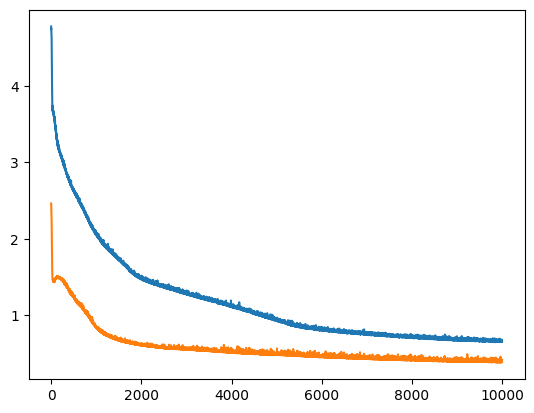

In [37]:
plt.plot(train_losses)
plt.plot(test_losses)
#bez dropoutu
#warstwy (29,50) (50, 50) (50, 50) (50, 50) (50, 29)
#tylko rzeczywiste

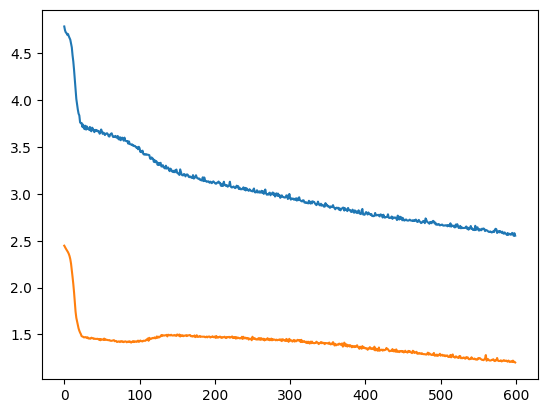

In [36]:
plt.plot(train_losses)
plt.plot(test_losses)
#bez dropoutu
#warstwy (29,50) (50, 50) (50, 50) (50, 50) (50, 29)
#tylko rzeczywiste

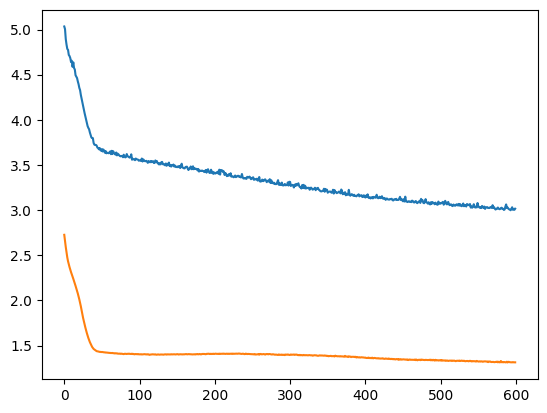

In [36]:
plt.plot(train_losses)
plt.plot(test_losses)
#bez dropoutu
#warstwy (29,50) (50, 50) (50, 29)
#tylko rzeczywiste

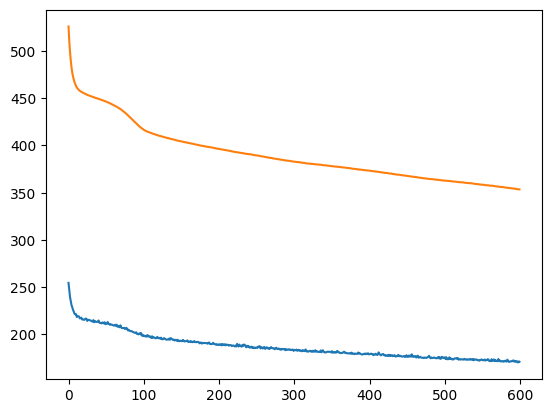

In [36]:
plt.plot(train_losses)
plt.plot(test_losses)
#bez dropoutu
#warstwy (29,50) (50, 50) (50, 29)
#całe dane

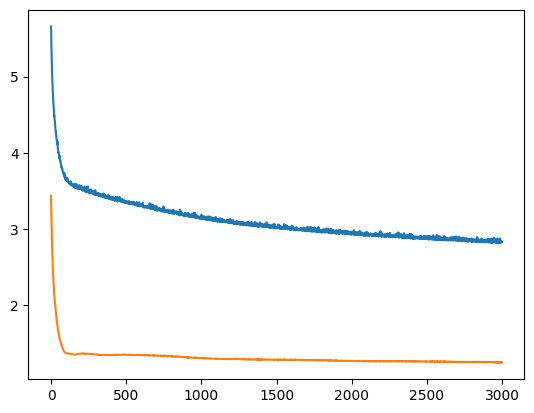

In [37]:
plt.plot(train_losses)
plt.plot(test_losses)
#bez dropoutu
#dwie warstwy (29,50) (50, 29)
#tylko rzeczywiste

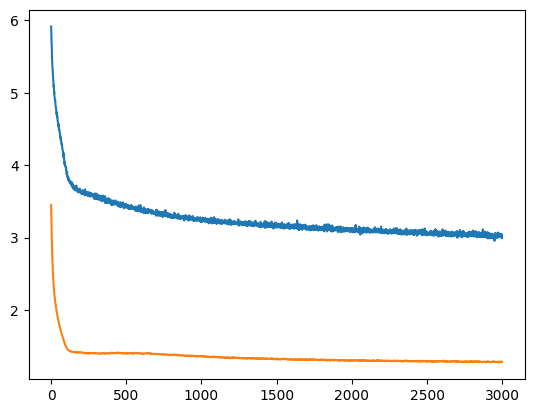

In [36]:
plt.plot(train_losses)
plt.plot(test_losses)
#3000 epoch
#dwie warstwy (29,50) (50, 29)
#tylko rzeczywiste

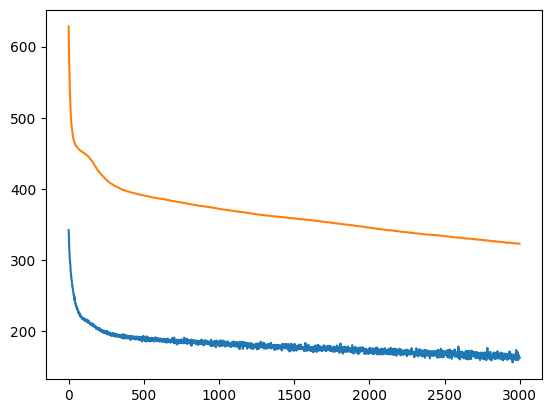

In [37]:
plt.plot(train_losses)
plt.plot(test_losses)
#3000 epoch
#dwie warstwy (29,50) (50, 29), dropout
#całe dane

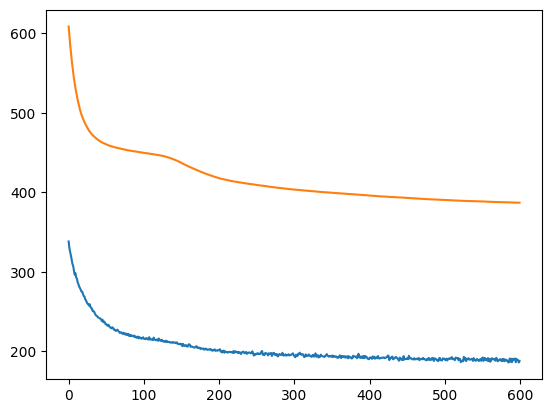

In [36]:
plt.plot(train_losses)
plt.plot(test_losses)
#600 epoch
#dwie warstwy (29,50) (50, 29), dropout
#całe dane

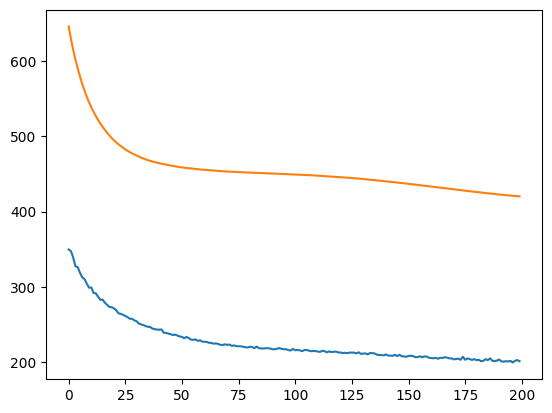

In [37]:
plt.plot(train_losses)
plt.plot(test_losses)
#200 epoch
#dwie warstwy (29,50) (50, 29), dropout
#całe dane

#### Poniżej: stara wersja sieci

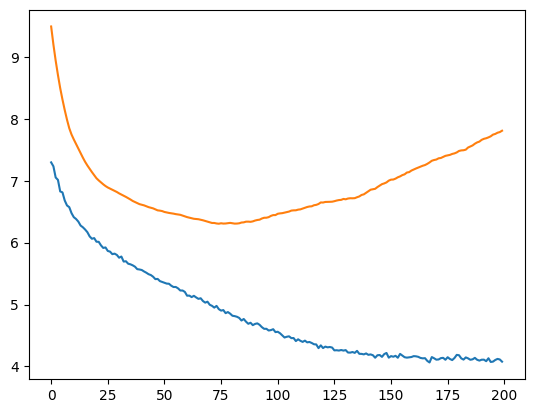

In [38]:
plt.plot(train_losses)
plt.plot(test_losses)
#plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Dropout(),
# nn.Linear(50,29))

#lr 0.0001
#batch size 100
#Adam
#tylko rzeczywiste

(0.0, 250.0)

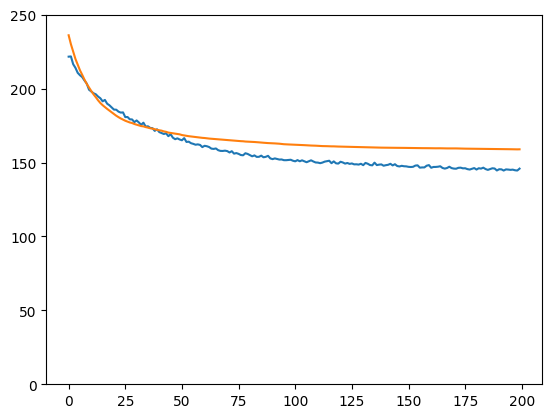

In [173]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Dropout(),
# nn.Linear(50,29))

#lr 0.0001
#batch size 100
#Adam

(0.0, 250.0)

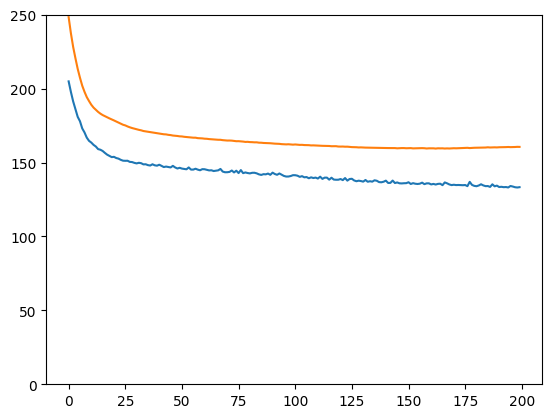

In [165]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Linear(50,29))

#lr 0.0001
#batch size 100
#Adam

(0.0, 250.0)

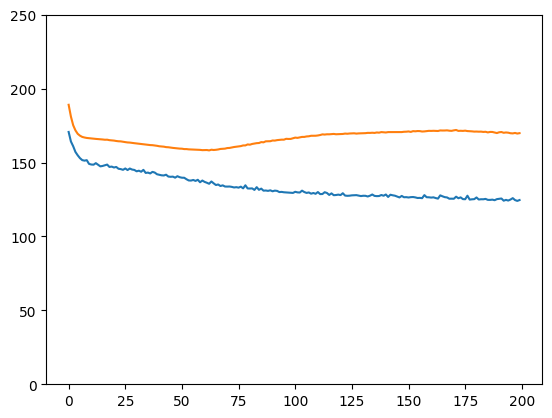

In [151]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Linear(50,100),
# nn.ReLU(),
# nn.Linear(100,29))

#lr 0.0001
#batch size 100
#Adam

(0.0, 250.0)

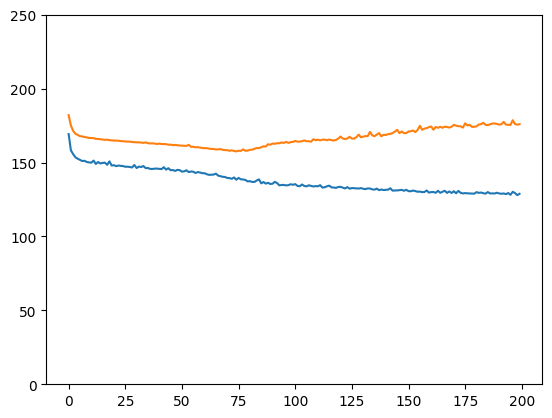

In [114]:
plt.plot(train_losses)
plt.plot(test_losses)
plt.ylim(0, 250)

# nn.Linear(29, 50),
# nn.ReLU(),
# nn.Linear(50,100),
# nn.ReLU(),
# nn.Linear(100,29))

#lr 0.0001
#batch size 100
#SGD

## Interpretability